<a href="https://colab.research.google.com/github/RAseng77/computer_vision_study/blob/main/study-notes/Untitled17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt

In [ ]:
transform = T.Compose([
    T.Grayscale(num_output_channels=3), # 1채널을 3채널로 변환

    T.Resize((224, 224)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(10),

    T.ToTensor(),
    T.Normalize(mean = [0.485, 0.456, 0.406],
                std = [0.229, 0.224, 0.225])
])

val_transform = T.Compose([
    T.Grayscale(num_output_channels=3),
    T.Resize((224,224)),
    T.ToTensor(),
    T.Normalize(mean = [0.485, 0.456, 0.406],
                std = [0.229, 0.224, 0.225])
])

In [ ]:
trainset = torchvision.datasets.FashionMNIST(root='/content/data', train=True, download=True, transform=transform)
testset = torchvision.datasets.FashionMNIST(root='/content/data', train=False, download=True, transform=val_transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=32, shuffle=False)

In [ ]:
image, label = trainset[0]

print(f"Image shape: {image.shape}")
print(f"Label: {label}")
print(f"Number of classess: {len(trainset.classes)}")

Image shape: torch.Size([3, 224, 224])
Label: 9
Number of classess: 10


In [ ]:
train_size = torch.tensor(len(trainset))
test_size = torch.tensor(len(testset))

print(f"Train dataset size: {train_size} (Shape: {train_size.shape})")
print(f"Test dataset size: {test_size} (Shape: {test_size.shape})")

Train dataset size: 60000 (Shape: torch.Size([]))
Test dataset size: 10000 (Shape: torch.Size([]))


In [ ]:
def imshow(img):
  img = img/ 2 + 0.5
  npimg = img.numpy()
  return np.transpose(npimg, (1, 2, 0))

In [ ]:
def show_multiple_images(dataset, n_images=9):
  dataiter = iter(dataset)
  images, labels = next(dataiter)
  fig, axes = plt.subplots(3, 3, figsize=(6, 6))
  axes = axes.flatten()

  for i in range(n_images):
    ax = axes[i]
    img = imshow(images[i])
    ax.imshow(img)
    ax.set_title(f"Label: {trainset.classes[labels[i]]}")
    ax.axis("off")

  plt.tight_layout()
  plt.show()

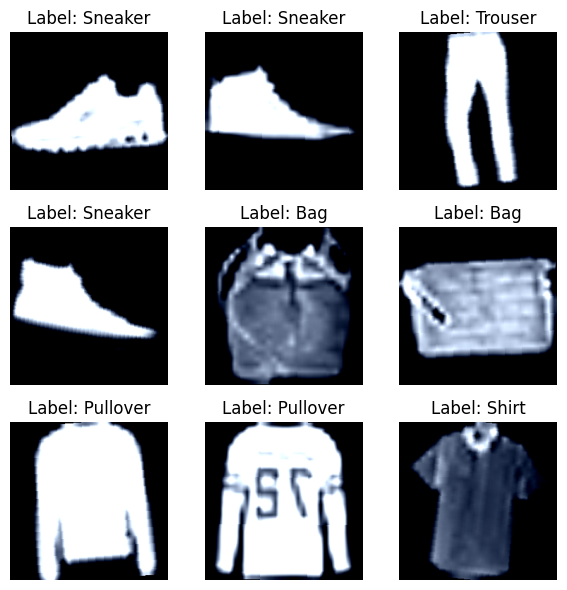

In [ ]:
show_multiple_images(trainloader)

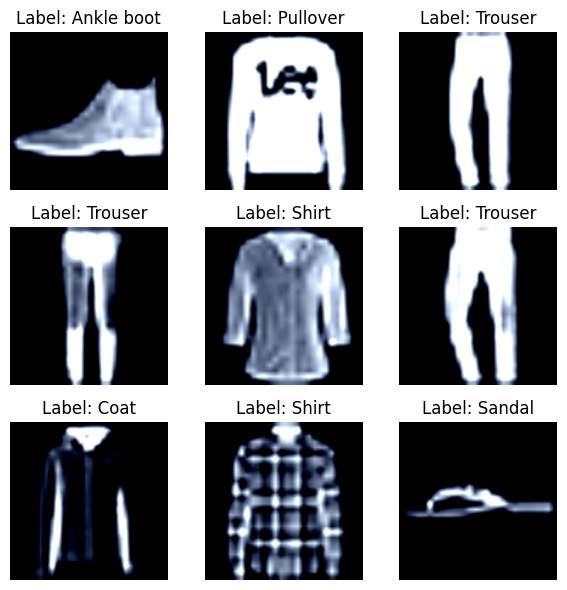

In [ ]:
show_multiple_images(testloader)

In [ ]:
def build_vgg_block(input_layer,
                    num_cnn=3,
                    channel=64,
                    block_num=1):

  #  입력 레이어
  x = input_layer

  # CNN 레이어
  layers = []
  in_channels = x.size(1)
  for cnn_num in range(num_cnn):
    layers.append(
        nn.Conv2d(
            in_channels=in_channels,
            out_channels=channel,
            kernel_size=3,
            stride=1,
            padding=1
        )
    )
    layers.append(nn.ReLU(inplace=True))
    in_channels=channel

  # Max Pooling 레이어
  layers.append(
      nn.MaxPool2d(
          kernel_size=2,
          stride=2
      )
  )

  # Sequential으로 레이어 묶기
  block = nn.Sequential(*layers)
  return block


In [ ]:
class VGGNet(nn.Module):
  def __init__(self):
    super(VGGNet, self).__init__()

    # VGG 블록 생성
    self.vgg_block = build_vgg_block(torch.zeros(1, 3, 32, 32))
  def forward(self, x):
    return self.vgg_block(x)

In [ ]:
model = VGGNet()
print(model)

dummy_input = torch.zeros(1, 3, 32, 32)
output = model(dummy_input)
print(output.shape)

VGGNet(
  (vgg_block): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
)
torch.Size([1, 64, 16, 16])


In [ ]:
class VGG(nn.Module):
  def __init__(self, num_cnn_list=[2, 2, 3, 3, 3], channel_list=[64, 128, 256, 512, 512], num_classes=10):
    super(VGG, self).__init__()
    assert len(num_cnn_list) == len(channel_list)

    layers = []
    in_channels = 3

    for num_cnn, out_channels in zip(num_cnn_list, channel_list):
      layers.append(self._make_vgg_block(in_channels, out_channels, num_cnn))
      in_channels = out_channels

    self.feature_extractor = nn.Sequential(*layers)
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(512 * 1 * 1, 4096),
        nn.ReLU(True),
        nn.Linear(4096, 4096),
        nn.ReLU(True),
        nn.Linear(4096, num_classes)
    )

  def _make_vgg_block(self, in_channels, out_channels, num_cnn):
    layers = [nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1), nn.ReLU(True)]
    for _ in range(num_cnn -1):
      layers.append(nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1))
      layers.append(nn.ReLU(True))
    layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
    return nn.Sequential(*layers)

  def forward(self, x):
    x = self.feature_extractor(x)
    x = self.classifier(x)
    return x

In [ ]:
vgg_16 = VGG()
print(vgg_16)

VGG(
  (feature_extractor): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), pa

In [ ]:
BATCH_SIZE = 64
EPOCH = 10

In [ ]:
import time

current_time = time.time()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vgg_16 = torchvision.models.vgg16(pretrained=True)
vgg_16.to(device)

for param in vgg_16.parameters():
  param.requires_grad = True
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(vgg_16.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)

vgg_16_train_losses = []
vgg_16_val_accuracy = []

for epoch in range(EPOCH):
  vgg_16.train()
  running_loss = 0.0
  correct = 0
  total = 0

  for i, (inputs, labels) in enumerate(trainloader, 0):
    inputs, labels = inputs.to(device), labels.to(device)

    optimizer.zero_grad()
    outputs = vgg_16(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    running_loss += loss.item()
    _, predicted = torch.max(outputs, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

    if i % 100 == 99:
      print(f"Epoch [{epoch+1}/{EPOCH}], Batch [{i+1}/{len(trainloader)}], Loss: {running_loss}")

  train_loss = running_loss / len(trainloader)
  train_acc = 100 * correct / total
  vgg_16_train_losses.append(train_loss)


  print(f"Epoch [{epoch+1}/{EPOCH}], Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.2f}%")

  vgg_16.eval()
  correct = 0
  total = 0

  with torch.no_grad():
    for inputs, labels in testloader:
      inputs, labels = inputs.to(device), labels.to(device)
      outputs = vgg_16(inputs)
      _, predicted = torch.max(outputs, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()

  val_acc = 100 * correct / total
  vgg_16_val_accuracy.append(val_acc)

  print(f"Epoch {epoch + 1}: Validation Accuracy: {val_acc:.2f}%")

print(f"Training time: {time.time() - current_time:.2f} seconds")

Epoch [1/10], Batch [100/1875], Loss: 174.8596264719963
Epoch [1/10], Batch [200/1875], Loss: 244.33501136302948
Epoch [1/10], Batch [300/1875], Loss: 295.7082031071186
Epoch [1/10], Batch [400/1875], Loss: 340.89527732878923
Epoch [1/10], Batch [500/1875], Loss: 386.8985925838351
Epoch [1/10], Batch [600/1875], Loss: 424.53989505022764
Epoch [1/10], Batch [700/1875], Loss: 461.3170272037387
Epoch [1/10], Batch [800/1875], Loss: 498.33429477363825
Epoch [1/10], Batch [900/1875], Loss: 532.0789063051343
Epoch [1/10], Batch [1000/1875], Loss: 565.1771070808172
Epoch [1/10], Batch [1100/1875], Loss: 599.717248313129
Epoch [1/10], Batch [1200/1875], Loss: 632.0755503326654
Epoch [1/10], Batch [1300/1875], Loss: 661.3426799252629
Epoch [1/10], Batch [1400/1875], Loss: 694.710348777473
Epoch [1/10], Batch [1500/1875], Loss: 723.034976169467
Epoch [1/10], Batch [1600/1875], Loss: 752.6010268628597
Epoch [1/10], Batch [1700/1875], Loss: 781.7283639237285
Epoch [1/10], Batch [1800/1875], Loss: 

In [ ]:
import torch.optim as optim

# --- 1. 모델 재초기화 (필수: 이전에 학습된 가중치를 초기화해야 공정한 비교가 됨) ---
# (모델을 다시 불러와야 SGD로 학습된 상태가 리셋됩니다)
vgg_adam = torchvision.models.vgg16(pretrained=True)
num_features = vgg_adam.classifier[6].in_features
vgg_adam.classifier[6] = nn.Linear(num_features, 10) # 10개 클래스
vgg_adam.to(device)

# --- 2. Adam 설정 ---
# SGD는 lr=0.001을 썼지만, Adam은 학습 속도가 빨라 0.0001(1e-4)이 국룰입니다.
optimizer = optim.Adam(vgg_adam.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss()

# 결과를 저장할 새로운 리스트 (덮어쓰기 방지)
adam_train_losses = []
adam_val_accuracy = []

print("Training with Adam optimizer started...")
start_time = time.time()

for epoch in range():
    vgg_adam.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (inputs, labels) in enumerate(trainloader, 0):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = vgg_adam(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    # 에포크별 Loss & Acc 계산
    train_loss = running_loss / len(trainloader)
    train_acc = 100 * correct / total

    adam_train_losses.append(train_loss) # Adam 결과 저장

    # Validation
    vgg_adam.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = vgg_adam(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    adam_val_accuracy.append(val_acc) # Adam 결과 저장

    print(f"Adam Epoch [{epoch+1}/{EPOCH}], Train Loss: {train_loss:.4f}, Val Acc: {val_acc:.2f}%")

print(f"Adam Training time: {time.time() - start_time:.2f} seconds")

Training with Adam optimizer started...
Adam Epoch [1/10], Train Loss: 0.3131, Val Acc: 89.63%
Adam Epoch [2/10], Train Loss: 0.2080, Val Acc: 92.73%
Adam Epoch [3/10], Train Loss: 0.1767, Val Acc: 93.67%
Adam Epoch [4/10], Train Loss: 0.1556, Val Acc: 93.62%
Adam Epoch [5/10], Train Loss: 0.1365, Val Acc: 94.00%
Adam Epoch [6/10], Train Loss: 0.1224, Val Acc: 94.00%


In [ ]:
import matplotlib.pyplot as plt

# 에폭 수 (X축 설정용)
epochs = range(1, len(vgg_16_train_losses) + 1)

plt.figure(figsize=(14, 6))

# 1. 학습 손실 (Train Loss) 비교 그래프
plt.subplot(1, 2, 1)
plt.plot(epochs, vgg_16_train_losses, 'b-o', label='SGD (Momentum)')
plt.plot(epochs, adam_train_losses, 'r-s', label='Adam')
plt.title('Training Loss Comparison', fontsize=15)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# 2. 검증 정확도 (Validation Accuracy) 비교 그래프
plt.subplot(1, 2, 2)
plt.plot(epochs, vgg_16_val_accuracy, 'b-o', label='SGD (Momentum)')
plt.plot(epochs, adam_val_accuracy, 'r-s', label='Adam')
plt.title('Validation Accuracy Comparison', fontsize=15)
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

NameError: name 'vgg_16_train_losses' is not defined